# Student Performance Predictor

### Machine Learning Open-Ended Lab

**Project Name:** Student Performance Predictor  
**Student Name:** Syeda Aaisha Fatima  
**Roll No:** _____24f-ai-055_____________  
**Program:** BS Artificial Intelligence  
**Course:** Machine Learning  
**University:** Dawood University of Engineering and Technology  

## Objective

To develop a machine learning application that predicts student academic
performance using student-related features.

The project integrates data preprocessing, data visualization, regression,
classification, and model evaluation.

### Machine Learning Models Used

1. Linear Regression — to predict the student's final grade (G3)
2. Logistic Regression — to predict whether the student will Pass or Fail

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)

In [4]:
from google.colab import files

uploaded = files.upload()

Saving student+performance.zip to student+performance.zip


In [7]:
import zipfile

with zipfile.ZipFile("student+performance.zip", "r") as zip_ref:
    zip_ref.extractall("student_data")

print("ZIP extracted successfully!")

ZIP extracted successfully!


In [8]:
with zipfile.ZipFile("student_data/student.zip", "r") as zip_ref:
    zip_ref.extractall("student_data/extracted")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [9]:
df = pd.read_csv(
    "student_data/extracted/student-mat.csv",
    sep=";"
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [10]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [11]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 395
Columns: 33


In [12]:
print(df.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


In [13]:
print(df.isnull().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [14]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [15]:
features = ["studytime", "absences", "G1", "G2"]

X = df[features]

y = df["G3"]

In [16]:
print(X.head())

   studytime  absences  G1  G2
0          2         6   5   6
1          2         4   5   5
2          2        10   7   8
3          3         2  15  14
4          2         4   6  10


In [17]:
print(y.head())

0     6
1     6
2    10
3    15
4    10
Name: G3, dtype: int64


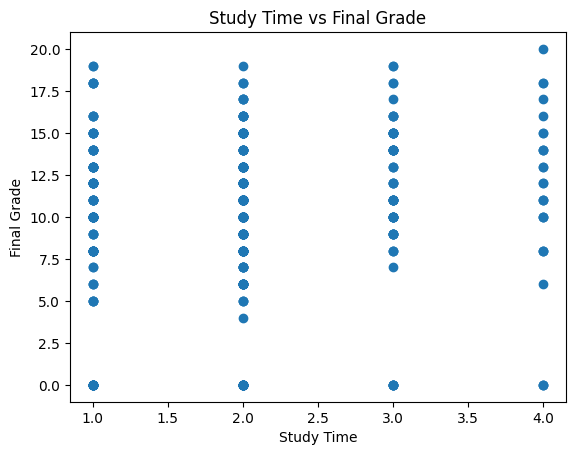

In [18]:
plt.scatter(
    df["studytime"],
    df["G3"]
)

plt.xlabel("Study Time")
plt.ylabel("Final Grade")
plt.title("Study Time vs Final Grade")

plt.show()

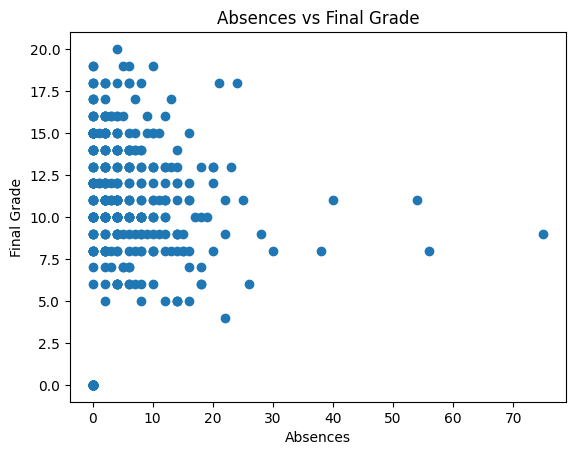

In [19]:
plt.scatter(
    df["absences"],
    df["G3"]
)

plt.xlabel("Absences")
plt.ylabel("Final Grade")
plt.title("Absences vs Final Grade")

plt.show()

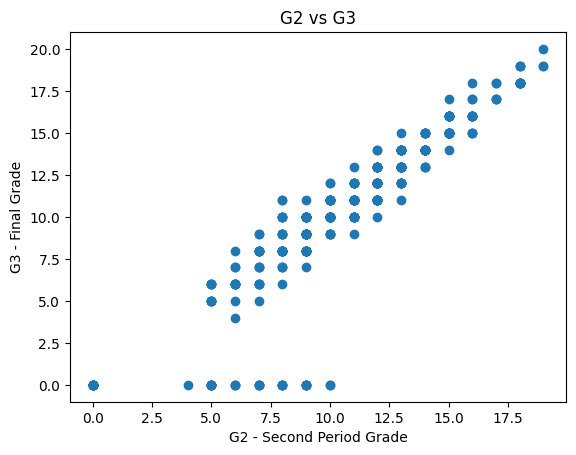

In [20]:
plt.scatter(
    df["G2"],
    df["G3"]
)

plt.xlabel("G2 - Second Period Grade")
plt.ylabel("G3 - Final Grade")
plt.title("G2 vs G3")

plt.show()

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (316, 4)
Testing data: (79, 4)


In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [25]:
scaler.fit_transform(X_train)

array([[-0.05685286, -0.46440769,  0.33205033,  0.62616324],
       [-1.25455313, -0.70225668,  0.64340909,  0.89283114],
       [-0.05685286, -0.70225668, -0.91338472, -0.97384417],
       ...,
       [-0.05685286,  1.08161077, -0.60202596, -0.44050837],
       [ 1.14084741, -0.70225668,  0.64340909,  1.15949904],
       [-1.25455313, -0.22655869, -0.2906672 ,  0.62616324]])

In [26]:
scaler.fit_transform(X_train)

array([[-0.05685286, -0.46440769,  0.33205033,  0.62616324],
       [-1.25455313, -0.70225668,  0.64340909,  0.89283114],
       [-0.05685286, -0.70225668, -0.91338472, -0.97384417],
       ...,
       [-0.05685286,  1.08161077, -0.60202596, -0.44050837],
       [ 1.14084741, -0.70225668,  0.64340909,  1.15949904],
       [-1.25455313, -0.22655869, -0.2906672 ,  0.62616324]])

In [27]:
model = LinearRegression()

In [28]:
model.fit(
    X_train_scaled,
    y_train
)

LinearRegression()

In [ ]:
model.fit(
    X_train_scaled,
    y_train
)

In [29]:
y_pred = model.predict(
    X_test_scaled
)

In [30]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

print("MAE:", mae)

MAE: 1.312574939624357


In [31]:
mse = mean_squared_error(
    y_test,
    y_pred
)

print("MSE:", mse)

MSE: 4.178975406386837


In [ ]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

In [ ]:
r2 = r2_score(
    y_test,
    y_pred
)

print("R²:", r2)

In [ ]:
plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs Predicted Final Grades")

plt.show()

In [ ]:
print(df["Pass"].value_counts())